In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [3]:
dataset = pd.read_pickle(
    r"C:\Users\apurb_oi8roye\Desktop/Health_sensing/datasets/sleep_breathing_dataset.pkl"
)


dataset.head()

,participant,start_time,end_time,airflow,thoracic,spo2,label
0,AP01,2024-05-30 20:59:00,2024-05-30 20:59:30,"[35.790966120347605, 34.51133827914673, 33.081...","[7.091772374978039, 7.283134996815348, 7.45489...","[0.00201119437291534, 0.22929201244903633, 0.4...",Normal
1,AP01,2024-05-30 20:59:15,2024-05-30 20:59:45,"[101.79175525253983, 106.19834641057996, 110.2...","[3.306370989275049, 4.118874331699022, 4.92026...","[-0.26623140547422125, -0.21257758462549278, -...",Normal
2,AP01,2024-05-30 20:59:30,2024-05-30 21:00:00,"[-69.53393835155659, -75.04113957547477, -80.2...","[-1.0689910557042994, -1.776358341396772, -2.4...","[-0.03663661195903428, -0.15660171298065237, -...",Normal
3,AP01,2024-05-30 20:59:45,2024-05-30 21:00:15,"[34.44758606869178, 26.72137808821756, 18.8986...","[-21.76285678221425, -22.115913596840006, -22....","[0.003915917206268893, 0.004363516317821149, 0...",Normal
4,AP01,2024-05-30 21:00:00,2024-05-30 21:00:30,"[-75.75040628944645, -82.00041006207795, -87.9...","[-6.46265421321025, -8.775231178399501, -11.04...","[0.0921629259732543, 0.0645221504939981, 0.002...",Normal


In [15]:
model_dir = r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\models"

os.makedirs(model_dir, exist_ok=True)

In [4]:
def prepare_signal(row):

    airflow = np.array(row["airflow"])
    thoracic = np.array(row["thoracic"])
    spo2 = np.array(row["spo2"])

    spo2 = np.pad(spo2, (0, 960-len(spo2)))

    signal = np.stack([airflow, thoracic, spo2])

    return signal

In [5]:
X = np.stack(dataset.apply(prepare_signal, axis=1))

le = LabelEncoder()

y = le.fit_transform(dataset["label"])

participants = dataset["participant"].values

In [6]:
class CNN1D(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.conv1 = nn.Conv1d(3,16,3,padding=1)
        self.pool = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16,32,3,padding=1)

        self.fc1 = nn.Linear(32*240,64)
        self.fc2 = nn.Linear(64,num_classes)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [7]:
unique_participants = np.unique(participants)

results = []

In [16]:
for test_p in unique_participants:

    print("Testing on", test_p)

    train_idx = participants != test_p
    test_idx = participants == test_p

    X_train = torch.tensor(X[train_idx], dtype=torch.float32)
    X_test = torch.tensor(X[test_idx], dtype=torch.float32)

    y_train = torch.tensor(y[train_idx], dtype=torch.long)
    y_test = torch.tensor(y[test_idx], dtype=torch.long)

    model = CNN1D(len(le.classes_))

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(5):

        optimizer.zero_grad()

        out = model(X_train)

        loss = loss_fn(out, y_train)

        loss.backward()

        optimizer.step()

    # Save trained model
    model_path = os.path.join(model_dir, f"cnn_{test_p}.pth")
    torch.save(model.state_dict(), model_path)

    print("Model saved:", model_path)

    # Evaluation
    model.eval()

    with torch.no_grad():

        preds = model(X_test).argmax(dim=1).numpy()

    y_true = y_test.numpy()

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average="weighted")
    rec = recall_score(y_true, preds, average="weighted")

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)

Testing on AP01
Model saved: C:\Users\apurb_oi8roye\Desktop\Health_sensing\models\cnn_AP01.pth


C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9478594950603733
Precision: 0.8984376223761057
Recall: 0.9478594950603733
Testing on AP02
Model saved: C:\Users\apurb_oi8roye\Desktop\Health_sensing\models\cnn_AP02.pth


C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9135104578858112
Precision: 0.8345013566667445
Recall: 0.9135104578858112
Testing on AP03
Model saved: C:\Users\apurb_oi8roye\Desktop\Health_sensing\models\cnn_AP03.pth


C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9899764150943396
Precision: 0.9800533024430402
Recall: 0.9899764150943396
Testing on AP04
Model saved: C:\Users\apurb_oi8roye\Desktop\Health_sensing\models\cnn_AP04.pth


C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9125258799171843
Precision: 0.8327034815186314
Recall: 0.9125258799171843
Testing on AP05
Model saved: C:\Users\apurb_oi8roye\Desktop\Health_sensing\models\cnn_AP05.pth
Accuracy: 0.7944339025932954
Precision: 0.6311252255896135
Recall: 0.7944339025932954


C:\Users\apurb_oi8roye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
results = np.array(results)

print("Average Accuracy:",results[:,0].mean())
print("Average Precision:",results[:,1].mean())
print("Average Recall:",results[:,2].mean())

Average Accuracy: 0.8260674877762952
Average Precision: 0.8352685029305851
Average Recall: 0.8260674877762948


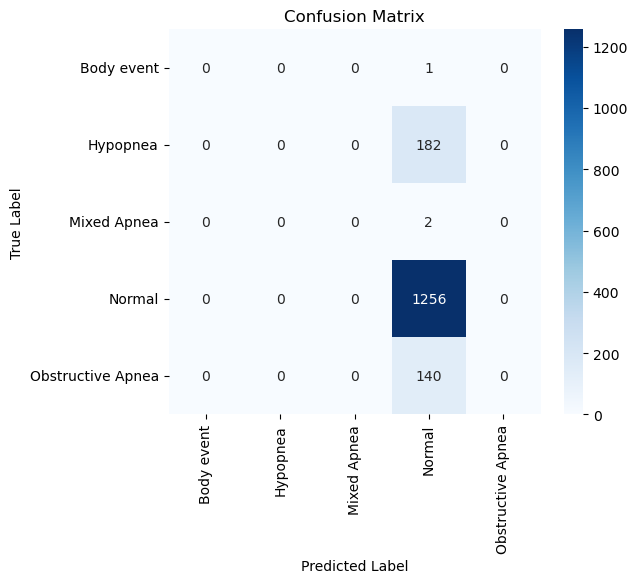

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
output_path=r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\Visualizations\Confusion_M"
plt.savefig(output_path)
plt.show()


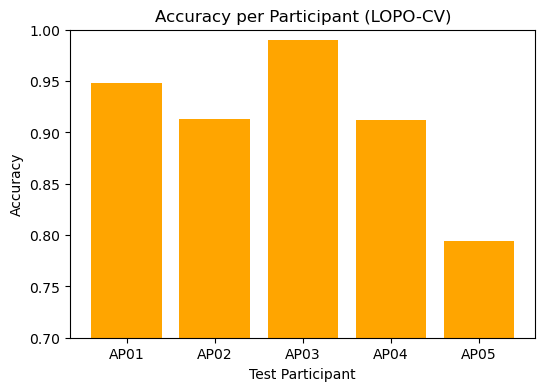

In [23]:
participants = ["AP01","AP02","AP03","AP04","AP05"]

accuracy = [
0.9479,
0.9135,
0.9899,
0.9125,
0.7944
]

plt.figure(figsize=(6,4))

plt.bar(participants,accuracy,color="orange")

plt.title("Accuracy per Participant (LOPO-CV)")
plt.xlabel("Test Participant")
plt.ylabel("Accuracy")

plt.ylim(0.7,1.0)
output_path=r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\Visualizations\Accuracy_P"
plt.savefig(output_path)
plt.show()